<a href="https://colab.research.google.com/github/CameshaBH/Python-project/blob/main/Copy_of_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Statistics - Assignment

The purpose of this assignment is to demonstrate that you understand fundamental statistical techniques, can use Python competently and can interpret the output. Do not assume that the analyses requested here would in practice be performed on this data; this is an exercise intended to allow you to show your understanding of basic statistics and your competence in using Python to carry out a range of statistical techniques.

Always remember when reviewing results that statistical significance does not mean clinical importance; for a dataset with many subjects a small and unimportant difference in what you are testing may give statistical significance.

Also remember that the purpose of this assignment is to assess your understanding of statistics. You are not expected to interpret the results in clinical or biological terms. When commenting on the results or making observations, please comment only on the relevant *statistical* aspects.

The assignment is based on a study to understand the prevalence of obesity, diabetes, and other cardiovascular risk factors in central Virginia for African Americans. Please read the [description of the data in the README document](https://github.com/jdtournier/MedPhysCourseAssignment/blob/main/README.md).

Remember as you consider your results that the population from which this sample was taken is not the general population of African Americans. This is a selected dataset – those subjects who were actually screened for diabetes.


# HOW TO CARRY OUT THIS ASSIGNMENT:

**Please make a copy of this notebook**, then provide your answers to the questions in the spaces provided. You are free to use as much space as you feel is needed to answer the question, but bear in mind that it's usually sufficient to write a few short sentences.

Once completed, please download your notebook as a `.ipynb` file (using the File → Download → download .ipynb menu), or alternatively download it from the 'Colab Notebooks' folder on your Google Drive. You can then submit this file as-is via KEATS.

**Make sure to fully justify any decisions you make,visualise the data where relevant, and investigate any assumptions made.** In particular:

-	where the output offers a choice of test and/or result you need to give some indication of why you made the choice you did

-	if possible an explanation of what the test statistic (e.g. *t*) actually means

-	an explanation of what the *p*-value really means

-	what conclusions you would draw from the results

-	any other comments you consider relevant to explain the results or justify their validity.

- where the questions asks for a model, don't forget to state the final equation for the model.

**Use as many text or code boxes as you need to answer the question!**

# Preamble

The code below loads all required modules and the data to be investigated. You can find the list of functions available [on this page](https://github.com/jdtournier/MedPhysStatsCourse).

Allow this section to run without modification!

In [30]:
import urllib
url = 'https://raw.githubusercontent.com/jdtournier/MedPhysStatsCourse/main/stats_course.py'

with open ('stats_course.py', 'wb') as data:
  data.write (urllib.request.urlopen(url).read())

from stats_course import *

df = load_data ('https://github.com/jdtournier/MedPhysCourseAssignment/raw/main/diabetes%20-%20raw%20data.csv')

# Before you start!

We need to perform a few steps to clean up the data first:

In [31]:
df.set_index ('id', inplace=True)
df.columns = [c.replace(".", "_") for c in list(df.columns)]

# Q1. Assess mean BMI	_[15 marks]_

According to the National Health and Nutrition Examination survey, the average BMI in the United States is 26.55 (average of both sexes).

- Compute a new variable `bmi` defined as 703×`weight`/`height`² (a correction factor of 703 is necessary when using pounds and inches).

- Perform the necessary steps to assess whether the mean BMI of the subjects in this dataset is significantly different from the general population.

- Explain the output & summarise your conclusions.

# Answer
**Null hypothesis(H0)**: There is no significant difference in mean BMI between the population and the sample i.e the BMI of the sample is 26.55

**Alternative hypothesis (H1)**: There is a significant difference in BMI between the population and the sample i.e. the BMI of the sample is not 26.55.

If p<=0.05, the result is statistically significant and we reject the null hypothesis. This means that the observed difference is not likely to be caused by chance and is not random. The p value represents the probability of observing the difference if the null hypothesis is true. Therefore, a small p value (less than significance value of 0.05) means that it is unlikely to be true.

A one-sample t-test will be performed as this test is used to determine if there is a statistically significant difference between the sample mean and the known population mean. While the t-test tells if there is significant difference, it does not tell how big the difference is. The t-test assumes the data is normally distributed.

Sample mean: 28.78457015698789
Sample standard deviation: 6.605889863253221
Sample count: 397


TtestResult(statistic=np.float64(6.739969312126765), pvalue=np.float64(5.611731867532117e-11), df=np.int64(396))

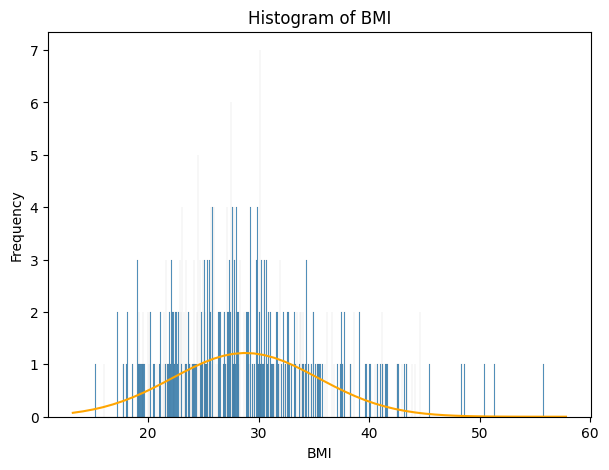

In [32]:
df['bmi'] = 703*df['weight']/df['height']**2 #function to create column and calculate bmi
bmi_mean_s = df['bmi'].mean() #calculate mean of sample
bmi_std_s = df['bmi'].std() #calculate standard deviation of sample
bmi_count_s = df['bmi'].count() #calculate count of sample
print('Sample mean:', bmi_mean_s) #print sample mean
print('Sample standard deviation:', bmi_std_s) #print sample standard deviation
print('Sample count:', bmi_count_s) #print number in sample

#create histogram to assess normality of the sample
y = df['bmi'] #define y variable to be plotted
width = 0.05 #define bin width
ax = sns.histplot(data=y, binwidth=width) #plot histogram
x = np.linspace (ax.get_xlim()[0], ax.get_xlim()[1]) #set locations to evaluate normal distribution
ax.plot (x, width*len(y)*stats.norm.pdf(x, y.mean(), y.std()), color='orange') #add normal curve to graph
ax.set_xlabel('BMI') #label x axis
ax.set_ylabel('Frequency') #label y axis
ax.set_title('Histogram of BMI') #add title to graph

bmi_mean_p = 26.55 #define mean bmi of population

#Perform statistical test (one sample t-test)
stats.ttest_1samp(df.bmi, bmi_mean_p, nan_policy='omit') #one sample two-tailed t-test

In [33]:
difference = bmi_mean_s - bmi_mean_p #calculate difference between sample mean and population mean
print('Difference between means:', difference); #print difference between mean of sample and population

Difference between means: 2.234570156987889


The histrograph shows that the sample distribution is roughly normally distributed so the assumption of the t-test holds true. The graph does show slight positive skewness which may affect the accuracy of the assumptions.

Since p = 5.612e-11 then  p < 0.05, therefore we **reject** the null hypothesis.

The one sample t-test had a t-value of 6. 73996 and a p-value of 0.00000000005612 which is much smaller than our significance level of 0.05. This means that the sample mean is 6.74 standard errors away from the population mean. The p-value tells us that the chance of observing this difference by chance is very small. The test shows 396 degrees of freedom and relatively large sample size. This sugguests that the results of the test are reliable.

This provides strong evidence to suggest that the mean BMI of the sample (28.78) is significantly different than the mean of the population (26.55). The sample mean is higher than the population mean. Our sample mean is higher than the mean of the population by 2.23 units.

# Q2. Compare BMI between subjects with and without diabetes _[10 marks]_

-	Compute a new variable `diabetes` computed as glycosylated haemoglobin (`glyhb`) > 7

- Compare mean BMI between those diagnosed with diabetes and those not diagnosed with diabetes.

- Explain the output & summarise your conclusions.

# Answer
**Null hypotheis (H0)**: the mean BMI of persons with diabetes is not significantly different from the mean BMI of persons without diabetes
**Alternative hypothesis (H1)**: the mean BMI of persons with diabetes is significantly different from the mean BMI of persons without diabetes

If p<=0.05, the result is statistically significant and we reject the null hypothesis. This means that the difference is not likely to be caused by chance and is not random.

Two-tailed independent sample t-test is used to assess the difference in means between two independent samples. It assesses the mean in both directions. In this example, we want to compare the mean BMI of persons with diabetes (sample 1) and persons without diabetes (sample 2).

In [34]:
df['diabetes'] = df['glyhb'] > 7 #determine if patient has diabetes from glycosylated haemoglobin. Adds a column in dataframe with 'True' if glyhb >7 so patient is diabetic or 'False' for glyhb<=7 so patient is not diabetic.
sample_stats = df.groupby('diabetes')['bmi'].agg(['mean', 'std', 'count']) #group data by diabetes status and calculate mean, standard deviation and count for each group
print(sample_stats) #print statistics of diabetic and non-diabetic patients

#print mean bmi of diabetic and non-diabetic patients
print('The mean BMI of diabetic patients:', df[df['diabetes']]['bmi'].mean())
print('The mean BMI of non-diabetic patients:', df[~df['diabetes']]['bmi'].mean())

#Performs independent 2-tailed two test to compare the mean of bmi of diabetic patients with the mean bmi of non-diabetic patients
stats.ttest_ind(df[df['diabetes']]['bmi'].dropna(), df[~df['diabetes']]['bmi'], nan_policy='omit')
diff = df[df['diabetes']]['bmi'].mean() - df[~df['diabetes']]['bmi'].mean() #calculate difference in b=mean BMI between samples
print('The difference in mean BMI between the two samples is:', diff) #print difference in mean BMI

               mean       std  count
diabetes                            
False     28.407910  6.580980    339
True      30.986084  6.369911     58
The mean BMI of diabetic patients: 30.986084169961554
The mean BMI of non-diabetic patients: 28.40790994237883
The difference in mean BMI between the two samples is: 2.578174227582725


The patients were classified into diabetic and non-diabetic based on if their glycosylateded haemoglobin was greater than 7.

The mean BMI of diabetic patients (n = 58) was 30.99 with standard deviation of 6.37.
The mean BMI of non-diabetic patients (n = 339) was 28.41 with a standard deviation of 6.58.

The independent sample t-test determined that the t-value = 2.76966 with 395 degrees of freedom and a p-value of 0.0058. Since p < 0.05, we can **reject** the null hypothesis. This means the difference in mean BMI between diabetic and non-diabetic patients is 2.77 standard errors away from zero, where zero represents the null hypothesis.  The chance of observing this difference due to chance is 0.0058 or 0.58%. The chance of observing this difference by chance is very small. The test shows 395 degrees of freedom and relatively large sample size. This suggests that the results of the test are reliable.

This provides strong evidence to suggest that the mean BMI of diabetic patients (30.99) is significantly different than the mean of non-diabetic patients (28.41). The mean BMI of diabetic patients is 2.58 units greater than mean BMI of non-diabetic patients.


In [35]:
#Perform Levene's test to check for variance between the samples
stats.levene (df[df['diabetes']==True]['bmi'].dropna(), df[df['diabetes']==False]['bmi'].dropna())

LeveneResult(statistic=np.float64(0.17072937778300223), pvalue=np.float64(0.6796886119070658))

Text(0.5, 1.0, 'Non-diabetic patients')

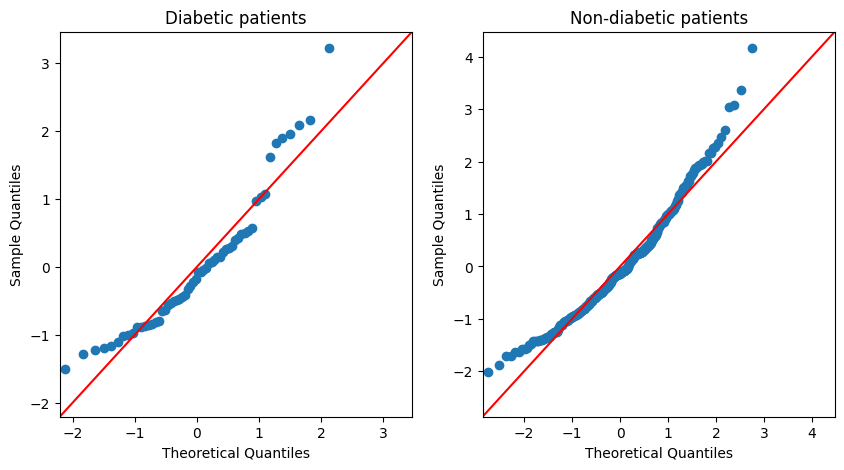

In [36]:
#Plot Q-Q plots for both data sets to assess normality
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sm.qqplot(df[df['diabetes']==True]['bmi'].dropna(), fit=True, line="45", ax=axes[0])
axes[0].set_title('Diabetic patients')
sm.qqplot(df[df['diabetes']==False]['bmi'].dropna(), fit=True, line="45", ax=axes[1])
axes[1].set_title('Non-diabetic patients')

**Testing assumptions of independent sample t-test**
1. Levene's test for variance
The levene's test is performed to determine there is variance between the two datasets.
Null hypothesis: There is no variance between the BMI of diabetic patients and non-diabetic patients.

Alternate hypothesis: There is variance between the BMI of diabetic and non-diabetic patients.

The results of the levene's test had a small statistic value of 0.17 and p-value of 0.68 which is greater than the 0.05 significance level. The low stastics value also means that the variance is similar in both groups. Therefore, we cannot reject the null hypothesis. We can assume that there is no variance between the BMI of diabetic and non-diabetic patients.

The two tail independent sample t-test assumes equal variance between the samples so this assumption has been met.

2. Q-Q plot to assess normality
The Q-plots show some deviation away from normality, particularly for diabetic patients. The Q-Q plot for non-daibetic patients is more normaly distributed with some deviation on the far side (slight positive skewness). This skewness may affect our assumption of normality, hence the reliability of the independent sample t-test as it assumes the data is normal. The Mann-Whatney U test is used to compare the distribution of two independent samples where assumptions of normality cannot be relied on.

<Axes: xlabel='diabetes', ylabel='bmi'>

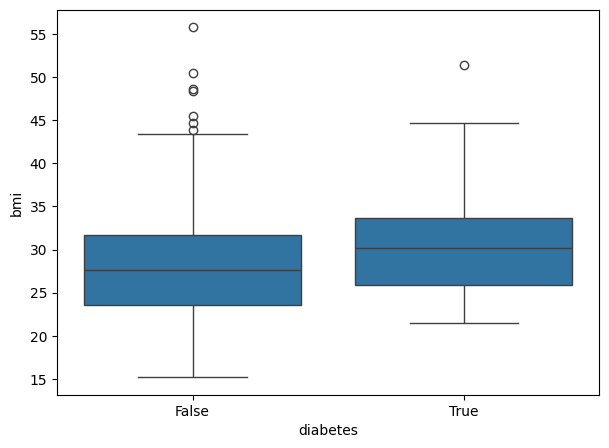

In [37]:
sns.boxplot (data=df, x='diabetes', y='bmi') #plot boxplot of bmi for diabetic and non-diabetic patient

The boxplot above compares the BMI of diabetic and non-diabetic patients. It visualises the statistics presented above and shows that the mean BMI of diabetic patients (TRUE) is greater than the mean BMI of non-diabetic patients (FALSE).

# Q3. Investigate relationship between diabetes and hypertension _[15 marks]_

Hypertension is defined as systolic blood pressure > 140.

- Compute a new variable `hypertension` as first systolic blood pressure (`bp_1s`) > 140

- What percentage of subject with `diabetes` also have `hypertension`?

- Perform the requisite steps to assess the relationship between `diabetes` and `hypertension`.

- Explain the output & summarise your conclusions.


# Answer
**Null hypothesis (H0):** There is no difference in the proportion of subjects who are diabetic and who are non-diabetic in the general population, who also have hypertensioni.e. there is no correlation between diabetes and hypertension.

**Alternative hypothesis (H1):** There is a difference in the proportion of subjects who are diabetic and who are non-diabetic in the general population, who also have hypertension i.e. there is correlation between diabetes and hypertension.

The chi-squared test is used here as it can compare two or more categories of data to determine if there is a statistically significant relationship between the groups. A chi-squared test of indepenence is performed to determine if there is a relationship between diabetes and hypertension.

In [38]:
df['hypertension'] = df['bp_1s'] > 140 #function to create column and calculate if patient has hypertension
print('Number of patients with hypertension:\n', df.hypertension.value_counts()) #count and print number of patients with hypertension
print('\nNumber of patients with diabetes:\n', df.diabetes.value_counts()) #count and print number of patients with diabetes
print('\nNumber of patients with diabetes and hypertension:\n', df.hypertension.loc[df.diabetes == True].value_counts()) #count and print number of patients with hypertension and diabetes

diab_hyp = (df.hypertension.loc[df.diabetes == True].value_counts()[True])/(df.diabetes.value_counts()[True])*100 #calculate percentage of patients with diabetes and hypertension
print('\nThe percentage of subject with diabetes who also have hypertension is', diab_hyp) #print percentage of patients with diabetes who also have hypertension

Number of patients with hypertension:
 hypertension
False    272
True     131
Name: count, dtype: int64

Number of patients with diabetes:
 diabetes
False    343
True      60
Name: count, dtype: int64

Number of patients with diabetes and hypertension:
 hypertension
True     37
False    23
Name: count, dtype: int64

The percentage of subject with diabetes who also have hypertension is 61.66666666666667


In [39]:
#Perform chi-squared test to test independence of diabetes and hypertension
table = sm.stats.Table.from_data(df[['hypertension', 'diabetes']]); #create crosstable with relevant tabs (subjects with hypertension and subjects with diabetes)
table.table_orig #print contingency table

diabetes,False,True
hypertension,,
False,249,23
True,94,37


<Axes: xlabel='hypertension'>

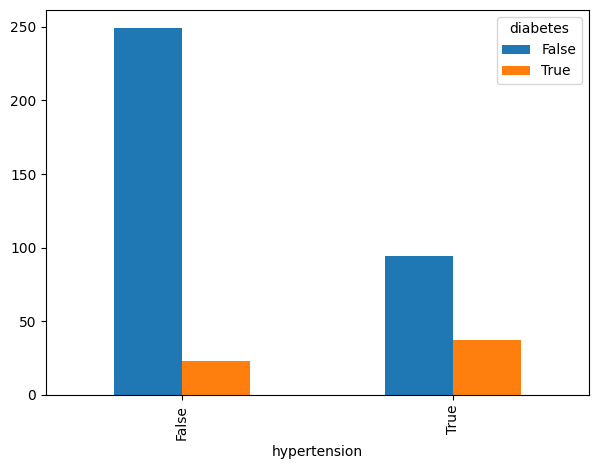

In [40]:
table.table_orig.plot(kind='bar') #create bargraph showing patients with diabetes and hypertension from cross table

In [41]:
table.fittedvalues #display frequency table

diabetes,False,True
hypertension,,
False,231.503722,40.496278
True,111.496278,19.503722


In [42]:
chi=table.test_nominal_association() #perforn chi-squared test
print(chi) #print results of chi-squared test

df          1
pvalue      1.7219337167251325e-07
statistic   27.322529615717606


The results show that 61.7% of diabetic patients also suffer with hypertension (1st systolic blood pressure greater than 140).

The chi-squared test of indepedence yielded a statistic of 27.33 with 1 degree of freedom and p-value of 0.000000172. The large chi-squared value (greater than value of 3.84) means that there is a significant difference between diabetic patients and non-diabetic patients who also have hypertension. The p-value of of 1.721e-7 is much less than significance value of 0.05, therefore we **reject** the null hypothesis. This indicates a high level of significance between diabetes and hypertension.

There is a signficant difference in the proportional of diabetic and non-diabetic patients with hypertension. Patients with diabetes have a significantly higher chance of having hypertension. There is evidence to suggest that patients with diabetes are more likely to have higher first systolic readings, hence, hypertension.
If there was no statistical significance, there would be a **2 in 10 million** chance getting this result. Therefore, there is strong evidence that the relationship is not random or by chance.


The bar chart above visually demonstrates this relationship. It shows that more diabetic patients (orange bar on chart) also have hypertension.


# Q4. Distribution of Cholesterol/HDL ratio	_[15 marks]_

Consider the distribution of Cholesterol/HDL ratio values (`chol_ratio` = `chol`/`hdl`). We have a lot of subjects, so for some analyses there is no problem with the distribution, but for other analyses it might be more helpful if the distribution was more normal.

- Is there a problem with the distribution of Cholesterol/HDL values? Present summary statistics and any plots you feel are appropriate to support your conclusions.

- How would you address this issue? Present histograms to show your conclusions.

# Answer


The following code will compute the chol_ratio and display summary statistics.

In [43]:
df['chol_ratio'] = df['chol']/df['hdl'] #compute ratio of cholesterol to HDL and add column to df
df['chol_ratio'].describe() #print summary statistics of chol_ratio

,chol_ratio
count,402.000000
mean,4.525892
std,1.725800
min,1.487179
25%,3.218681
50%,4.260870
75%,5.424013
max,19.260870


The results are shown highlighted below:

range of data = min to max, therefore, range of data =1.487179 to 19.260870

median is equal to the 50% or 2nd quartile, therefore median = 4.26087

1st quartile = 25% quartile = 3.218681

3rd quartile = 75% quartile = 5.424013

The Pearson skewness coefficient is a statistical test used to assess assymetry of data. The results of this test range from -1 to 1. A skewness coefficient of 0 represents perfectly normal data (i.e. no skewness). A positive value indicates positive or right skewness. This means that the data has a longer tail on the right side. A negative value indicates negative or left skewness. This means that the tail is longer on the left side. This test will be used to determine the normality of the data.

Kurtosis or Shapiro-Wilk test may be used to increase robustness of assessment.

In [44]:
skewness = 3*(df['chol_ratio'].mean()-df['chol_ratio'].median())/df['chol_ratio'].std() #calculate Pearson skewness coefficient of chol_ratio
print('Pearson skewness coefficient =', skewness) #print Pearson skewness coefficient values

Pearson skewness coefficient = 0.46069536153214785


A Pearson skewness coefficient of 0.46 represents mild to moderate positive skewness, hence the data is not perfectly normal. Moderate skewness is considered to be betweeen 0.4 and 0.7. We expect most values to be concentrated on the left side, with some larger values on the right side. This can be visually inspected using histograms, boxplots and Q-Q plots.

The mean tends to be more heavily influenced than median by skewness. Mean of sample found to be 4.53 while median found to be 4.26. This shows very small right or positive skewness since the mean is slightly larger than the median. It is difficult to comment on the significance between the mean and median by only assessing the descriptive statistics.

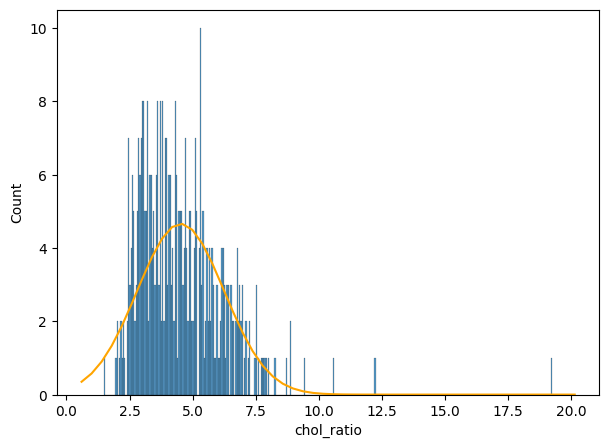

In [45]:
#plot histogram of chol_ratio with normal curve overlay
y=df['chol_ratio'] #define y variable to be plotted
width = 0.05 #bin width
ax=sns.histplot(data=y, binwidth=width) #plot histogram
x = np.linspace (ax.get_xlim()[0], ax.get_xlim()[1]) #set locations to evaluate normal distribution
ax.plot (x, width*len(y)*stats.norm.pdf(x, y.mean(), y.std()), color='orange') #use mean and std to add curve to graph

The histogram indicates a near-normal distribution with a slight positive skewness, as expected based on Pearson skewness coefficient. There are more values on the left and more extreme values on the right.

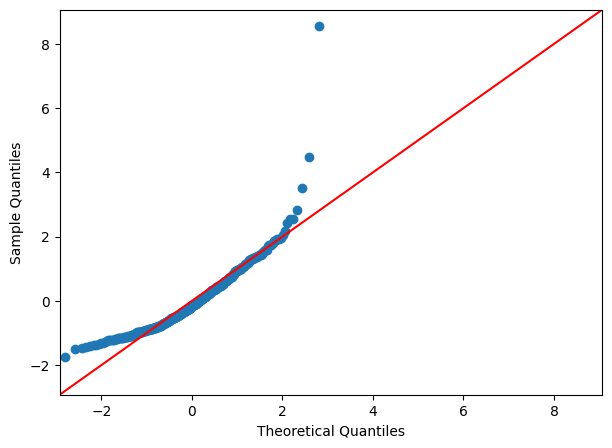

In [46]:
sm.qqplot (df.chol_ratio.dropna(), fit=True, line='45'); #create and display Q-Q plot for chol_ratio

The Q-Q plot shoes deviation from the normal lime (red line) at the tails of the curve, with greater deviaiton on the right. This verifies right (positive) skewness of the data. It shows the presents of extreme values on the right side.

<Axes: ylabel='chol_ratio'>

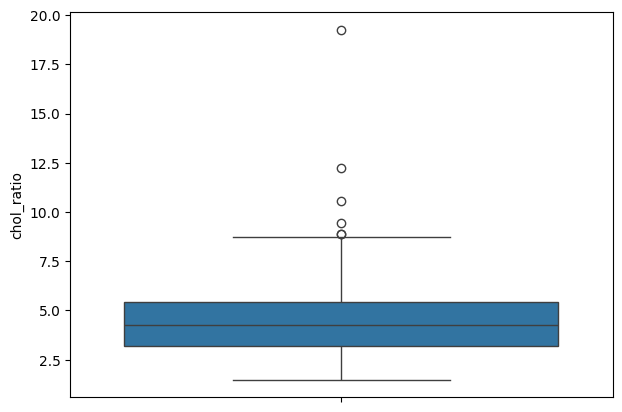

In [47]:
#plot boxplot to show chol_ratio distribution
sns.boxplot (data=df['chol_ratio'])

The boxplots show positive outliers which cause positive skewness observed in histoplot. Outliers are more than 1.5 x IQR but less than 3 x IQR.
Remove outliers can reduce skewness and create normal distribution.

Pearson skewness coefficient when outliers removed = 0.4135808813575177


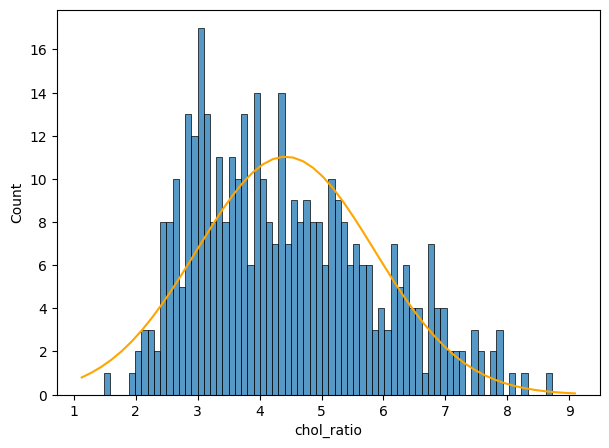

In [48]:
#Remove outliers which are values beyond 1.5 times the IQR from the quartiles
Q1 = df['chol_ratio'].quantile(0.25) #calculate 1st quartile
Q3 = df['chol_ratio'].quantile(0.75) #calculate 3rd quartile
IQR =  df['chol_ratio'].quantile(0.75) - df['chol_ratio'].quantile(0.25)# calculate interquartile range
remove_outliers = df[~((df['chol_ratio'] < (Q1 - 1.5 * IQR)) | (df['chol_ratio'] > (Q3 + 1.5 * IQR)))] #stores chol_ratio values that are not outliers

#Plot histogram of chol_ratio without outliers with normal curve overlay
y = remove_outliers['chol_ratio']
width = 0.1
ax = sns.histplot(data=y, binwidth=width)
x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1])
ax.plot(x, width * len(y) * stats.norm.pdf(x, y.mean(), y.std()), color='orange')

#Calculate Pearson skewness coefficient of chol_ratio with outliers removed
skewness2 = 3*(remove_outliers.chol_ratio.mean()-remove_outliers.chol_ratio.median())/remove_outliers.chol_ratio.std() #calculate Pearson skewness coefficient of chol_ratio
print('Pearson skewness coefficient when outliers removed =', skewness2) #print Pearson skewness coefficient values

Once the outliers have been removed, the dispersion of data looks more like the normal distribution curve with little skewness. However, the Pearson skewness coefficient is 0.41. While this has decreased, the data still displays moderate positive skewness.

Another approach to reducing skewness is log transformation. This will be assessed below.

Pearson skewness coefficient of log_chol_ratio = -0.014897775379268055


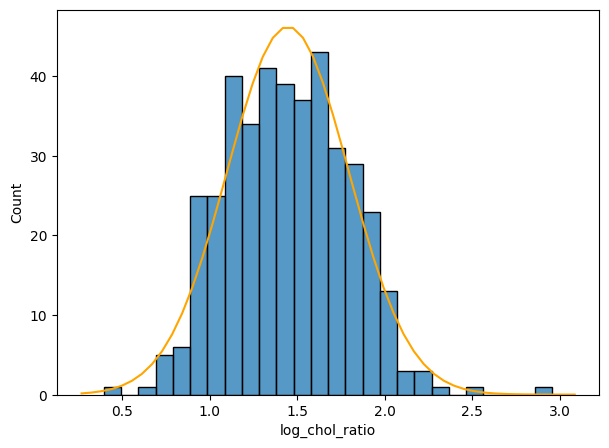

In [49]:
df['log_chol_ratio'] = np.log(df['chol_ratio']) #compute log of chol_ratio and add column to df

#Plot histogram of log_chol_ratio with normal curve overlay
y = df.log_chol_ratio
width = 0.1
ax = sns.histplot(data=y, binwidth=width)
x = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1])
ax.plot(x, width * len(y) * stats.norm.pdf(x, y.mean(), y.std()), color='orange')

#Perform Pearson skewness test on log_chol_ratio to assess normality
skewness = 3*(df.log_chol_ratio.mean()-df.log_chol_ratio.median())/df.log_chol_ratio.std() #calculate Pearson skewness coefficient of chol_ratio
print('Pearson skewness coefficient of log_chol_ratio =', skewness) #print Pearson skewness coefficient values

The histograph of the log of chol_ratio shows a more normal distribution. The Pearson skewness coefficient of the log of chol_ratio is -0.015 which demonstrates only mild negative (left sided) skewness.

Of the two approaches tests, the log transformation was more effective at reducing skewness to achieve a normal distribution. Normality is an assumption of some statististical test such as the t-test and one-way analsis of variance (ANOVA). It is important to ensure normality for these types of tests, however, this may not be necessary for non-parametric tests. Based on these results, log transformation is the more suitable method for parametric statistical analysis as it produced the best approximation of normality.

# Q5. Relate stabilized glucose to glycosylated haemoglobin in diabetes cases	_[15 marks]_

- Select those cases with a diagnosis of diabetes

- Create a simple linear regression model to relate stabilized glucose (independent variable) to glycosylated hemoglobin (dependent variable)

- Comment on the model & its generalisability.

# **Answer**
**Null hypothesis (H0):** Stabilised glucose (stab_glu) has no effect on glycosylated haemoglobin (glyhb) i.e. there is no linear relationship between stab_glu and glyhb.

**Alternate hypothesis (H1):** There is correlation between stabilised glucose (stab_glu) and glycosylated haemoglobin (glyhb) i.e. there is a linear relationship betwen stab_glu and glyhb.

If p < 0.05 then reject the null hypothesis.

Linear regression is used to model the relationship between two variables; a dependent variable and an independent variable. It assumes a linear relationship between these variables. Linear regression assumes a normal distribution of residuals and that all observations are independent.

In [50]:
#perform linear regression
linear_regression = smf.ols('glyhb ~ stab_glu', data=df.loc[df.diabetes == True]).fit()
#.loc[df.diabetes == True] selects values only for patients who have been diagnosed with diabetes i.e glyhb>7print(linear_regression.summary())
print(linear_regression.summary()) #print summary statistics of the linear regression

                            OLS Regression Results                            
Dep. Variable:                  glyhb   R-squared:                       0.256
Model:                            OLS   Adj. R-squared:                  0.243
Method:                 Least Squares   F-statistic:                     19.91
Date:                Thu, 15 May 2025   Prob (F-statistic):           3.80e-05
Time:                        09:42:10   Log-Likelihood:                -125.48
No. Observations:                  60   AIC:                             255.0
Df Residuals:                      58   BIC:                             259.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.2389      0.699     10.350      0.0

This questions evaluated the relationship between glycosylated haemoglobin (dependent variable) and stabilised glucose (independent variable) in diabetic patients. There were 60 patients included in the sample. The model fitted by the linear regression is : glyhb = 7.2389 + 0.0149*stab_glu. This means that for each unit of increase of stab_glu, glyb increased by 0.0149.

The p-valueof 0 is less than the level of significance of 0.05.
F-statistics = 19.91 and F-statistic probability = 0.000038 which is smaller than significance value of p = 0.05.Therefore, we **reject** the null hypothesis.  glycosylated haemoglobin is controlled by or correlates to stabilised glucose i.e. stabilised glucose is a predictor of glycosylated haemoglobin. The F-statistics is high and means that a large proportion of variance in glycosylated haemoglobin is explained by stabilised glucose.

R squared of 0.256 means that 25.6% of glycosylated haemoglobin can be explained by stabilised glucose.

The adjusted R-squared value of 0.243 is only slightly lower than R-squared as there is only one dependent variable tested. This small R^2 value suggests that there may be other factors not included in the model which are controlling glycosylated haemoglobin.

There is strong evidence to sugguest that the model is statistically significant. Stabilised glucose is a strong predictor of glycosylated haemoglobin.


# Assessing residuals

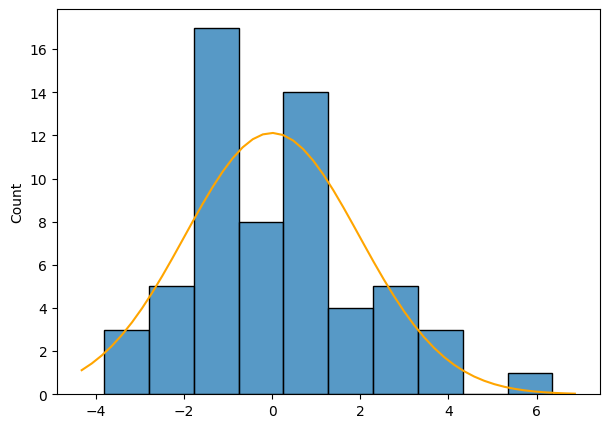

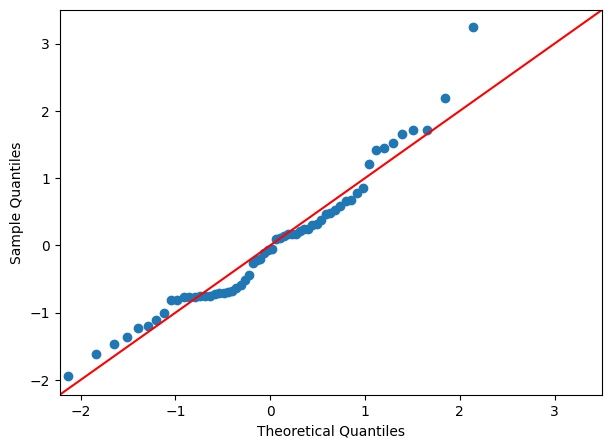

In [51]:
ax = sns.histplot (linear_regression.resid, binwidth=1) #create histoplot of the residuals from linear regression
add_Normal (ax, linear_regression.resid, 1); #add normal line to hisplot
sm.qqplot(linear_regression.resid, fit=True, line="45"); #create QQ plot of residuals

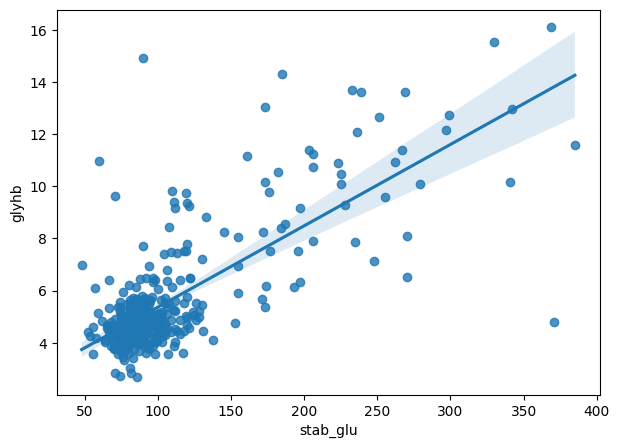

In [52]:
sns.regplot(data=df, x='stab_glu', y='glyhb'); #plot data with linear regression model fit

The histoplot regression scatter plot shows a near-normal distributon of residuals with a slight right/positive skewness. This may mean that there are positive outliers. There are also peaks and throughs at the centre of the curve which show some deviation from the normal distribution.

The quartile-quartile (Q-Q) plot shows that the residuals roughly follow the predicted values. Deviation is seen on the far right (upper end) which shows that there are positive outliers within the residuals. This aligns with right sided skewness observed in the histoplot.

This skewness may influence the regression model as it assumes the sample is has a normal distribution.


**Generalisability of the model**
While there is statistical significance showing that glycosylated haemoglobin is controlled by stabilised glucose, the model only explains 25% of the variance. This means that there may be other factors affecting/controlling glycosylated haemoglobin. There may be other predictors affecting this variance. Also, the residuals demonstrate a small positive (right sided) skewness which will affect its ability to be generalised. Only one predictor was used in the model so there is little chance of overfit of the model, however, the sample size of 60 is not very large and may not be representative of the population. This model is ideal for modeling of this sample, but may not be generalisable to the entire population.

# Q6. Find the best model to predict glycosylated haemoglobin	_[15 marks]_

Use the *p*-value-based  backward selection method to identify the most appropriate model to predict glycosylated haemoglobin (`glyhb`) within the subjects diagnosed as having diabetes.

- Include the following variables: `stab_glu`, `chol`, `hdl`, `chol_ratio`, `age`, `weight`, `height`, `bmi`, `waist`, `hip`, `bp_1s`, `gender`, `location`

- Comment on the model & its generalisability.

In [53]:
#Backward stepwise multiple linear regression based on p-value
#variables = ['stab_glu', 'chol', 'hdl', 'chol_ratio', 'age', 'weight', 'height', 'bmi', 'waist', 'hip', 'bp_1s', 'gender', 'location'] #define variables to be assessed in model
#gender and location found to not be signficant but caused error so removed manually
variables = ['stab_glu', 'chol', 'hdl', 'chol_ratio', 'age', 'weight', 'height', 'bmi', 'waist', 'hip', 'bp_1s'] #define variables to be assessed in model
result = stepwise_backward_pval(df.loc[df.diabetes == True], 'glyhb', variables) #perform backward stepwise method
print(result.summary()) #print summary of results of backward stepwise method


  glyhb ~ stab_glu + chol + hdl + chol_ratio + age + weight + height + bmi + waist + hip + bp_1s : R² = 0.36145336490788593
    Intercept, p = 0.150703590221915
    stab_glu, p = 9.406053717033613e-05
    chol, p = 0.046233089435516954
    hdl, p = 0.8109896119730602
    chol_ratio, p = 0.5647343958514237
    age, p = 0.21081786100110067
    weight, p = 0.28354517010852365
    height, p = 0.29735028628880195
    bmi, p = 0.1443537845450008
    waist, p = 0.9233030092810145
    hip, p = 0.15390428812385926
    bp_1s, p = 0.01849085856823452

removing waist with p = 0.9233030092810145

  glyhb ~ stab_glu + chol + hdl + chol_ratio + age + weight + height + bmi + hip + bp_1s : R² = 0.37491214939611206
    Intercept, p = 0.14452629843754608
    stab_glu, p = 7.392085401555489e-05
    chol, p = 0.04399299522494703
    hdl, p = 0.8079951950049069
    chol_ratio, p = 0.5622007111123983
    age, p = 0.1810486452117316
    weight, p = 0.2802621423204932
    height, p = 0.2886531493917071
    bmi

The backward stepwise linear regression was used to determine and appropriate model. This method performs the linear regression with all possible predictors then uses the p-value to remove poor predictors. It first removes the variable with the largest p-value which is greater than the significance level of 0.1. The regression is then performed for the other variables. It then reports the final fitted model with all variables with p-values less than significance level of 0.1.

The method started with 13 variables and filtered this down to only four variables. The final model shows that there is a statistical significant relationship between stablised glucose, cholestol, bmi and first systolic blood pressure with glycosylated haemoglobin in patients diagnosed with diabetes.

The predicted model follows the equation 11.5635 + 0.0138*stab_glu + 0.0135*chol - 0.0730*bmi - 0.0338*bp_1s. This means:
*   each unit increase of stabilised glucose causes an increase of glycosylated haemoglobin 0.0138
*   each unit increase of cholesterol causes an increase of glycosylated haemoglobin by 0.0135
*   each unit increase of BMI caused a decrease of glycosylated haemoglobin by 0.0730
*   each unit increase of 1st systolic blood pressure caused a decrease of glycosylated haemoglobin by 0.00338.


The model has 53 degrees of freedom while the residuals have 4 degrees of freedom. The F-statistic value  is 9.708 with a probability of 0.00000528.The F-statstic value is greater than significance level of 4.028  at the 0.05 level. Therefore, the model shows statistical significance between the variables and glycosylated haemoglobin.

The p-values for the variables show that:
*   stabilised glucose (p = 0.000) demonstrates a strong significant relationship with glycosylated haemoglobin and increases as explain in the model above.
*   cholesterol (p = 0.005) demonstrates a strong to modertately significant relationship with glycosylated haemoglobin and increases as explain in the model above.
*   bp_1s (p = 0.008) demonstrates a strong to modertately significant relationship with glycosylated haemoglobin and decreases as explain in the model above.
*   BMI (p = 0.0056) demonstrates a weak (at p =0.01 significance level) to borderline (at 0.05 significance level) relationship with glycosylated haemoglobin and decreases as explain in the model above.

These values are statistically significant as they are smaller than significance level of 0.1.

R-squared value is 0.425 which means that the model explains 42.5% of the variance in glycosylated haemoglobin. The model has moderate predictive power.
The adjusted R-squared value of 0.381 accounts for multiple predictors within the model and adjusts for overfitting. The value is slightly lower than the R^2 value which means that there is little overfitting by the model.


Text(0.5, 1.0, 'Actual vs Predicted glycosylated haemoglobin values')

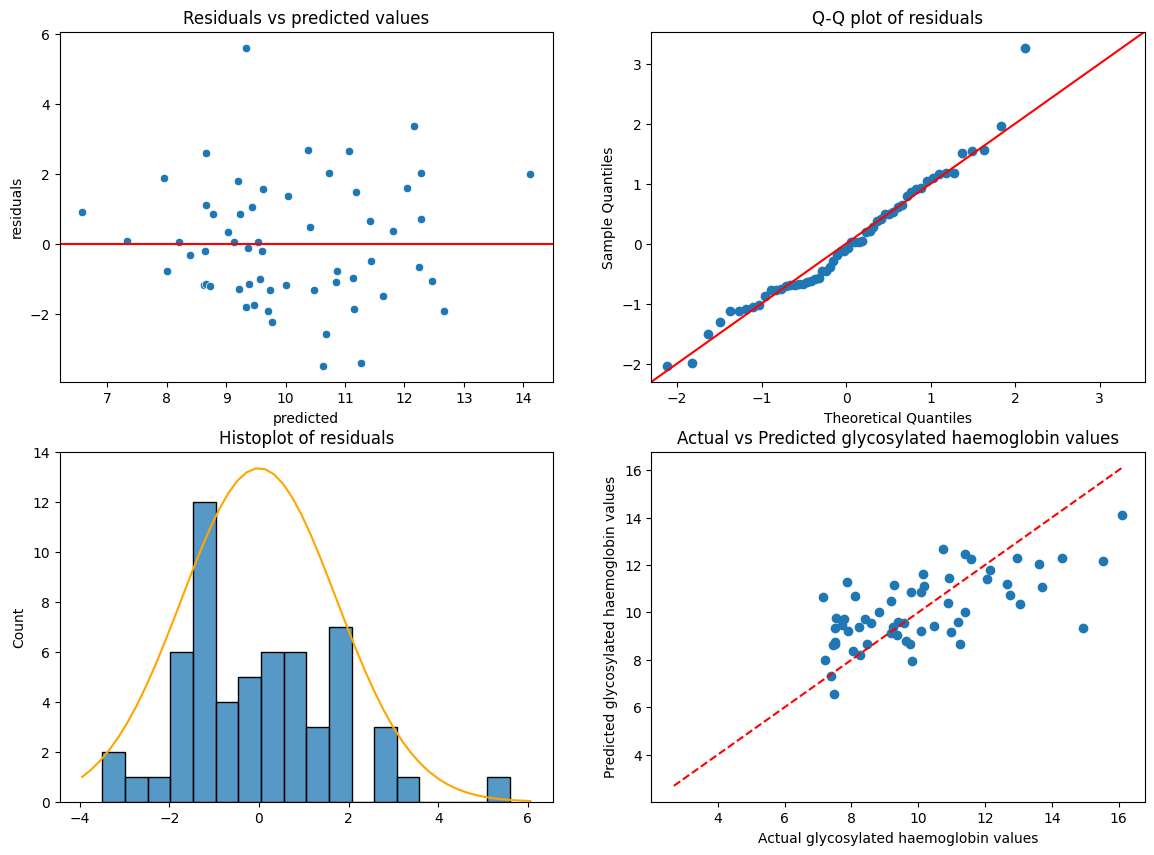

In [54]:
#Create plots to visualise data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

#create scatterplot of residuals and predicted values
data = pd.concat ([result.fittedvalues, result.resid], axis=1, keys=['predicted', 'residuals']) #merge residuals and fitted values into a single df
sns.scatterplot (data=data, x='predicted', y='residuals', ax=axes[0,0]); #create scatter plot of residuals vs predicted values
axes[0,0].axhline(y=0, color='r', linestyle='-') #add horizontal line to plot
axes[0,0].set_title('Residuals vs predicted values') #add title to plot

#Create Q-Q plot
sm.qqplot(result.resid, fit=True, line="45", ax=axes[0,1]);
axes[0,1].set_title('Q-Q plot of residuals') #add title to plot

#Create histoplot of residuals
ax = sns.histplot (result.resid, binwidth=0.5, ax=axes[1,0])
add_Normal (ax, result.resid, 1) #add normal line to plot
axes[1,0].set_title('Histoplot of residuals') #add title to plot

#Scatterplot to compare original vs predicted values
axes[1,1].scatter(df.loc[result.fittedvalues.index]['glyhb'], result.fittedvalues)
axes[1,1].plot([min(df['glyhb']), max(df['glyhb'])], [min(df['glyhb']), max(df['glyhb'])], 'r--')
axes[1,1].set_xlabel('Actual glycosylated haemoglobin values') #add x label to plot
axes[1,1].set_ylabel('Predicted glycosylated haemoglobin values') #add y label to plot
axes[1,1].set_title('Actual vs Predicted glycosylated haemoglobin values') #add title to plot

The graphs show a roughly normal distribution of residuals with slight positive skewness. This may affect the relaibility of the p-values.

The variance inflation factor (VIF) can be used to detect multicollinearity in regression models. Multicollinearity refers to variables being highly correlated with each other. A VIF of 1 indicates no multicollinearity with other variables. Values less than 5 are typically acceptable as having little collinearity which will affect regression coefficients.

This test will be performed below.

In [55]:
VIF (result.model) # calculate variance inflation factor for model and returns result. VIF function uses functions from stats module for computation

,0
stab_glu,1.004278
chol,1.140819
bmi,1.001147
bp_1s,1.140406


The results of the VIF shows that the variables have low multicollinearity as the values are only slighly greater than 1. This means that the variables (stabilised glucose, cholestorol, BMI and 1st systolic blood pressure) are not correlated with each other and so will not impact the regression coefficients. We can be more confident in the reliability of the model.

**Generalisability of the model**
*   The model shows little multicollinearity which would have impacted the regression coefficients and hence its predicitive power. Multicollinearity means that variables may correlate with each other making it difficult to use the model as a predictor.
*   The analysis of the residuals (QQ plot and histoplot) show slight right/positive skewness which may affect the reliability of the p-values.
*   The R value shows that the model only explains 42.5% of the variance of glycosylated haemoglobin. This means that a large proportion of the variance is not explained by the model. There may be other predictors affecting this variance which have not been included in the analysis.
*   The regression analysis has a sample size of 58 (2 likely removed due to missing values) with 4 predictors. This is adequate but still quite small in comparison to the larger dataset. A larger sample size would increase the robustness of the generalisability.
* The model should be tested on an independent dataset to assess its generalisability and predictive power.

# Q7. Prediction of diagnosis of diabetes _[15 marks]_

-	Create a new variable `wh_ratio` computed as the ratio of `waist` to `hip`
- Use binary logistic regression to assess whether it is possible to predict diagnosis of diabetes from a combination of some or all of the following risk factors:

  - age > 60
  - body mass index > 30
  - gender
  - waist/hip ratio > 1
  - cholesterol/HDL ratio > 7
  - hypertension

- Summarise the main conclusions.

**Null (H0) hypothesis:** None of the variables (age over 60, BMI over 30, gender, waist.hip ratio over 1, cholesterol/hdl ratio over 7 and hypertension) explain the outcome (diabetes diagnosis)

**Alternate (H1) hypothesis: ** At least one of the variables explain the diabetes diagnosis.

In [56]:
df['wh_ratio'] = df['waist']/df['hip'] #compute wh_ratio by dividing waist by hip and adding column to df

#Convert variables to binary
df['sex'] = [ 1 if x=='male' else 0 if x=='female' else -1 for x in df['gender'] ] #convert gender to numerical value 1 for Male and 0 for Female
df['hypertensive'] = [1 if x is True else 0 if x is False else -1 for x in df['hypertension'] ] #convert hypertension to numerical value 1 for True and 0 for False
df['body_mass_index'] = [1 if x > 30 else 0 if x <= 30 else -1 for x in df['bmi']] #convert hypertension to numerical value with 1 for bmi >30 and 0 for bmi <=30
df['ages'] = [1 if x > 60 else 0 if x <= 60 else -1 for x in df['age']] #convert age to numerical value with 1 for age >60 and 0 for age <=60
df['waist_hip_ratio'] = [1 if x > 1 else 0 if x <= 1 else -1 for x in df['wh_ratio']] #convert wh_ratio to numerical value with 1 for wh_ratio >1 and 0 for wh_ratio<=1
df['chol_hdl_ratio'] = [1 if x > 7 else 0 if x <= 7 else -1 for x in df['chol_ratio']] #convert chol_ratio to numerical value with 1 for chol_ratio >7 and 0 for chol_ratio<=7
df['diabetic'] = [1 if x is True else 0 if x is False else -1 for x in df['diabetes']] #convert diabetes to numerical value 1 for True and 0 for False
model_df = df.dropna(subset=['wh_ratio', 'sex', 'hypertensive', 'body_mass_index', 'ages', 'waist_hip_ratio', 'chol_hdl_ratio', 'diabetic']) #drop rows with missing values in

#Use binary logistic regression to determine model
model = smf.logit('diabetic ~ ages + sex + hypertensive + body_mass_index + waist_hip_ratio + chol_hdl_ratio', data=model_df).fit() #use binary logic regression to determine model
print (model.summary()); #print summary of the model

Optimization terminated successfully.
         Current function value: 0.356057
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               diabetic   No. Observations:                  401
Model:                          Logit   Df Residuals:                      394
Method:                           MLE   Df Model:                            6
Date:                Thu, 15 May 2025   Pseudo R-squ.:                  0.1564
Time:                        09:42:12   Log-Likelihood:                -142.78
converged:                       True   LL-Null:                       -169.25
Covariance Type:            nonrobust   LLR p-value:                 1.210e-09
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -2.6940      0.306     -8.792      0.000      -3.295      -2.093
ages          

In this example, binary regression logistics was used to determine if the following are risk factors for diabetes:
*   age over 60
*   BMI > 30
*   gender
*   waist-hip ratio > 1
*   cholesterol-HDL ratio > 7
*   Hypertension
All categorical predictors were converted to binary variables and defined in code.

The equation of the model is -2.694 + 0.8397*ages - 0.1293*sex + 1.1353*hypertensive + 0.0596*body_mass_index + 0.0831*waist_hip_ratio + 2.118*Chol_hdl_ratio.

The Pseduo R^2 value = 0.1564 which means that this model explains ~15.64% of the variation in diabetes diagnosis. While this explains a moderate amount of the variation, a large proportion is still unexplained by this model.

LLR p-value is the likelihood ratio p-value test. It compares the model with all predictors/variables against the model without predictors. The value was determined to be 1.210e-9 which is much less than significance level of 0.05, so we **reject** the null hypothesis. There is strong evidence to sugguest that at least one predictors improves the models ability to predict diabetes.

3 of these 6 variables were shown to be significant: age over 60 (p = 0.012, z = 2.519), hypertension (p = 0.000, z = 3.512), and cholesterol-HDL ratio greater than 7 (p = 0.000, z = 4.484). Sex (p = 0.691, z = -0.398), BMI (p = 0.849, z = 0.191) and waist-hip ratio (p = 0.896, z = 0.131) were not shown to be significant at the 0.05 significance level.

The z-value is the ratio of the coefficient to the standard error and tells how many standard deviations away from zero the coefficient is. Larger z values means that the coefficient is further away from zero, and so are significant. At the 0.05 significance level, z-values greater than 1.96 or less than -1.96 are stastically significant. The z-values determined by the binary logistic regressions shows that age over 60, hypertension and cholesterol-HDL ratio over 7 are highly significant while sex, BMI over 30 and waist-hip ratio greater than 1 are not significant. This aligns with our p-values explained above.

The model parameters and odds ratio are displayed and explained below.

In [57]:
print('Model parameters\n', model.params); #print model parameters
print('\nOdds-ratio\n', np.exp(model.params)); #compute  and print odds ratio table

Model parameters
 Intercept         -2.693981
ages               0.839717
sex               -0.129299
hypertensive       1.135251
body_mass_index    0.059580
waist_hip_ratio    0.083150
chol_hdl_ratio     2.117972
dtype: float64

Odds-ratio
 Intercept          0.067611
ages               2.315711
sex                0.878711
hypertensive       3.111954
body_mass_index    1.061391
waist_hip_ratio    1.086705
chol_hdl_ratio     8.314260
dtype: float64


This results means that:

*   age over 60 increases the log-odds ratio by 0.84 and the odds of being diabetic by 2.32. This means persons over 60 have 2.32 times higher odds of diabetes than persons younger than 60.
*   sex (being male) decreases the log-odds ratio by 0.13 and the odds of of being diabetic by 0.88. The p-value and z-value show that this is not statistically significant.
*   having hypertension increases the log-odds ratio by 1.14 and the odds of being diabetic by 3.11. This means persons with hypertension have 3.11 higher odds of diabetes than persons without hypertension.
*   Having a BMI over 30 increases the log-odds ratio by 0.06 and the odds of being diabetic by 1.06. The p-value and z-value determined that this is not statistically significant.
*   having a waist-hip ratio greater than 1 increases the log-odds ratio by 0.08 and the odds of being diabetic by 1.09. The p-value and z-value shows that this is not statistically significant.
*   having cholesterol-HDL ratio greater than 7 increases the log-odds ratio by 2.11 and the odds of being diabetic by 8.31. This means that persons with cholesterol/HDL ratio greater than 7 have 8.31 higher odds of diabetes than persons with lower chol_ratio. The bigger odds value means this is the strongest predictor of diabetes in this model.

Therefore, age over 60, being hypertensive and having cholesterol-HDL ratio greater than 7 are strong predictors of diabetes.







In [58]:
#determine confusion matrix to assess the models ability to correctly classify/group data
print(model.pred_table()) #print model prediction table with number of cases falling in each group

[[336.   5.]
 [ 49.  11.]]


The confusion matrix table above demonstrates the models ability to correctly classify patients based on diabetes diagnosis.
The table shows:

number of true negatives = 336

number of false negatives = 49  (81.7%)

number of true positives = 11

number of false positives = 5 (1.5%)

The model correctly identifies 347 of 401 cases correctly, so has an overall accuracy of 86.5%. The model correctly identified 11 of the 60 (18.3%) positive cases of diabetes and 336 of 341 (98.5%) negative cases. This table shows that the model is better at identifying negative cases/non-diabetic patients (so has high specifity) but is poor at detecting positve cases/diabetic patients (so has low sensitivity).

*   model accuracy = 86.5%
*   Specificity = 18.3%
*   Sensitivity = 98.5%
